# Nạp thư viện và dữ liệu

In [141]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

try:
    import seaborn as sns
except ImportError as e:
    raise ImportError("Chưa cài seaborn. Hãy chạy: !pip install seaborn") from e

# Cấu hình để hiển thị biểu đồ ngay trong notebook
%matplotlib inline

In [142]:
possible_paths = [
    Path("Online_Retail.xlsx"),
    Path("/mnt/data/Online_Retail.xlsx"),
    Path(r"C:\Users\NEU\Downloads\Online_Retail.xlsx"),
]

data_path = next((p for p in possible_paths if p.exists()), None)

if data_path is None:
    raise FileNotFoundError(
        "Không tìm thấy file Online_Retail.xlsx. "
        "Hãy đặt file cùng thư mục với notebook hoặc cập nhật lại biến `possible_paths`."
    )

df = pd.read_excel(data_path)
df

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
...,...,...,...,...,...,...,...,...
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,2011-12-09 12:50:00,0.85,12680.0,France
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,12680.0,France
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680.0,France
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680.0,France


In [143]:
df.describe()

,Quantity,InvoiceDate,UnitPrice,CustomerID
count,541909.000000,541909,541909.000000,406829.000000
mean,9.552250,2011-07-04 13:34:57.156386,4.611114,15287.690570
min,-80995.000000,2010-12-01 08:26:00,-11062.060000,12346.000000
25%,1.000000,2011-03-28 11:34:00,1.250000,13953.000000
50%,3.000000,2011-07-19 17:17:00,2.080000,15152.000000
75%,10.000000,2011-10-19 11:27:00,4.130000,16791.000000
max,80995.000000,2011-12-09 12:50:00,38970.000000,18287.000000
std,218.081158,NaN,96.759853,1713.600303


In [144]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[us]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  str           
dtypes: datetime64[us](1), float64(2), int64(1), object(3), str(1)
memory usage: 33.1+ MB


# Xử lý dữ liệu thô

In [145]:
# Tính tổng số dòng trùng
print(df.duplicated().sum())

# Tạo dữ liệu ms với Dataframe đã lược bỏ các dòng trùng
df = df.drop_duplicates()

# print(df.duplicated().sum()).Ktra lại xem đã loại bỏ hết trùng lặp chưa
print(df.duplicated().sum())

5268
0


In [146]:
# xóa dữ liệu dòng trống customer id
df = df.dropna(subset=['CustomerID']).copy()
df.isnull().sum()

InvoiceNo      0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
UnitPrice      0
CustomerID     0
Country        0
dtype: int64

In [147]:
df.info()

<class 'pandas.DataFrame'>
Index: 401604 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    401604 non-null  object        
 1   StockCode    401604 non-null  object        
 2   Description  401604 non-null  object        
 3   Quantity     401604 non-null  int64         
 4   InvoiceDate  401604 non-null  datetime64[us]
 5   UnitPrice    401604 non-null  float64       
 6   CustomerID   401604 non-null  float64       
 7   Country      401604 non-null  str           
dtypes: datetime64[us](1), float64(2), int64(1), object(3), str(1)
memory usage: 27.6+ MB


In [148]:
# lọc các dòng thỏa mãn điều kiện "InvoiceNo" ko bắt đầu bằng "C"
df = df[~df["InvoiceNo"].str.startswith("C", na=False)]
df.info()

<class 'pandas.DataFrame'>
Index: 392732 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    392732 non-null  object        
 1   StockCode    392732 non-null  object        
 2   Description  392732 non-null  object        
 3   Quantity     392732 non-null  int64         
 4   InvoiceDate  392732 non-null  datetime64[us]
 5   UnitPrice    392732 non-null  float64       
 6   CustomerID   392732 non-null  float64       
 7   Country      392732 non-null  str           
dtypes: datetime64[us](1), float64(2), int64(1), object(3), str(1)
memory usage: 27.0+ MB


In [149]:
# loại bỏ các dòng có số lượng hoặc đơn giá nhỏ hơn hoặc bằng 0
df = df[(df['Quantity'] > 0) & (df['UnitPrice'] > 0)].copy()
df.info()

<class 'pandas.DataFrame'>
Index: 392692 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    392692 non-null  object        
 1   StockCode    392692 non-null  object        
 2   Description  392692 non-null  object        
 3   Quantity     392692 non-null  int64         
 4   InvoiceDate  392692 non-null  datetime64[us]
 5   UnitPrice    392692 non-null  float64       
 6   CustomerID   392692 non-null  float64       
 7   Country      392692 non-null  str           
dtypes: datetime64[us](1), float64(2), int64(1), object(3), str(1)
memory usage: 27.0+ MB


In [150]:
# astype(int). cột customer id đang ở dạng float 1232.00 đổi sang dạng int 1232
# astype(str). đổi dữ liệu từ int ở trên 1232 sang dạng chuỗi vb "1232"
df['CustomerID'] = df['CustomerID'].astype(int).astype(str)
df.info()

<class 'pandas.DataFrame'>
Index: 392692 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    392692 non-null  object        
 1   StockCode    392692 non-null  object        
 2   Description  392692 non-null  object        
 3   Quantity     392692 non-null  int64         
 4   InvoiceDate  392692 non-null  datetime64[us]
 5   UnitPrice    392692 non-null  float64       
 6   CustomerID   392692 non-null  str           
 7   Country      392692 non-null  str           
dtypes: datetime64[us](1), float64(1), int64(1), object(3), str(2)
memory usage: 27.0+ MB


In [151]:
# chuyển cột InvoiceDate sang datetime để so sánh thời gian
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"], errors='coerce')
df = df.dropna(subset=['InvoiceDate']).copy()
df.info()

<class 'pandas.DataFrame'>
Index: 392692 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    392692 non-null  object        
 1   StockCode    392692 non-null  object        
 2   Description  392692 non-null  object        
 3   Quantity     392692 non-null  int64         
 4   InvoiceDate  392692 non-null  datetime64[us]
 5   UnitPrice    392692 non-null  float64       
 6   CustomerID   392692 non-null  str           
 7   Country      392692 non-null  str           
dtypes: datetime64[us](1), float64(1), int64(1), object(3), str(2)
memory usage: 27.0+ MB


# Tính toán R F M

In [152]:
# tạo cột tổng tiền mỗi giao dịch.
df['TotalPrice'] = df['Quantity']*df['UnitPrice']
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalPrice
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34


In [153]:
# dữ liệu đang đến hết tháng 12/2011, nhưng sẽ lấy dữ liệu đến hết tháng 11 để train
# phần tháng 12 dùng để test khả năng quay lại mua của khách hàng
df_train = df[df['InvoiceDate'] < '2011-12-01'].copy()
df_test = df[df['InvoiceDate'] >= '2011-12-01'].copy()

# ngày mốc để tính Recency
now = df_train['InvoiceDate'].max() + pd.DateOffset(days=1)
print(now)

2011-12-01 17:37:00


In [154]:
# nhóm dữ liệu theo customer id, sau đó tính các chỉ số RFM
rfm = df_train.groupby('CustomerID').agg(
    Recency=('InvoiceDate', lambda x: (now - x.max()).days),  # ngày mua gần nhất của khách
    Frequency=('InvoiceNo', 'nunique'),                       # số hóa đơn khác nhau
    Monetary=('TotalPrice', 'sum')                           # tổng số tiền đã chi
)

# Gán nhãn quay lại mua trong tập test
returning_customers = df_test['CustomerID'].astype(int).astype(str).unique()
rfm['returned'] = rfm.index.isin(returning_customers).astype(int)

rfm.info()
rfm.head()

<class 'pandas.DataFrame'>
Index: 4297 entries, 12346 to 18287
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Recency    4297 non-null   int64  
 1   Frequency  4297 non-null   int64  
 2   Monetary   4297 non-null   float64
 3   returned   4297 non-null   int64  
dtypes: float64(1), int64(3)
memory usage: 167.9+ KB


,Recency,Frequency,Monetary,returned
CustomerID,,,,
12346,317,1,77183.60,0
12347,31,6,4085.18,1
12348,67,4,1797.24,0
12349,10,1,1757.55,0
12350,302,1,334.40,0


# Khử lệch và chuẩn hóa

Recency       1.214683
Frequency    12.027696
Monetary     20.129756
returned      2.154874
dtype: float64


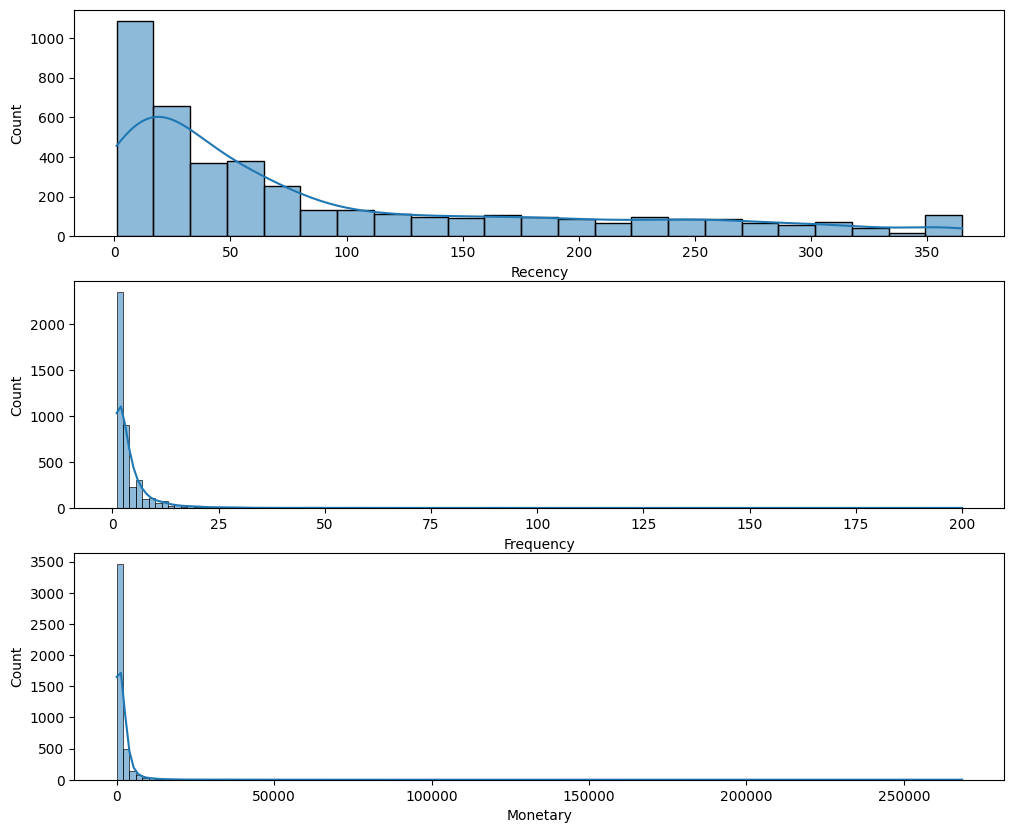

In [155]:
# Kiểm tra độ lệch 
print(rfm.skew())

# Vẽ biểu đồ phân phối
import seaborn as sns
import matplotlib.pyplot as plt

fig, axes = plt.subplots(3, 1, figsize=(12, 10))
sns.histplot(rfm['Recency'], kde=True, ax=axes[0])
sns.histplot(rfm['Frequency'], kde=True, ax=axes[1])
sns.histplot(rfm['Monetary'], kde=True, ax=axes[2])
plt.show()

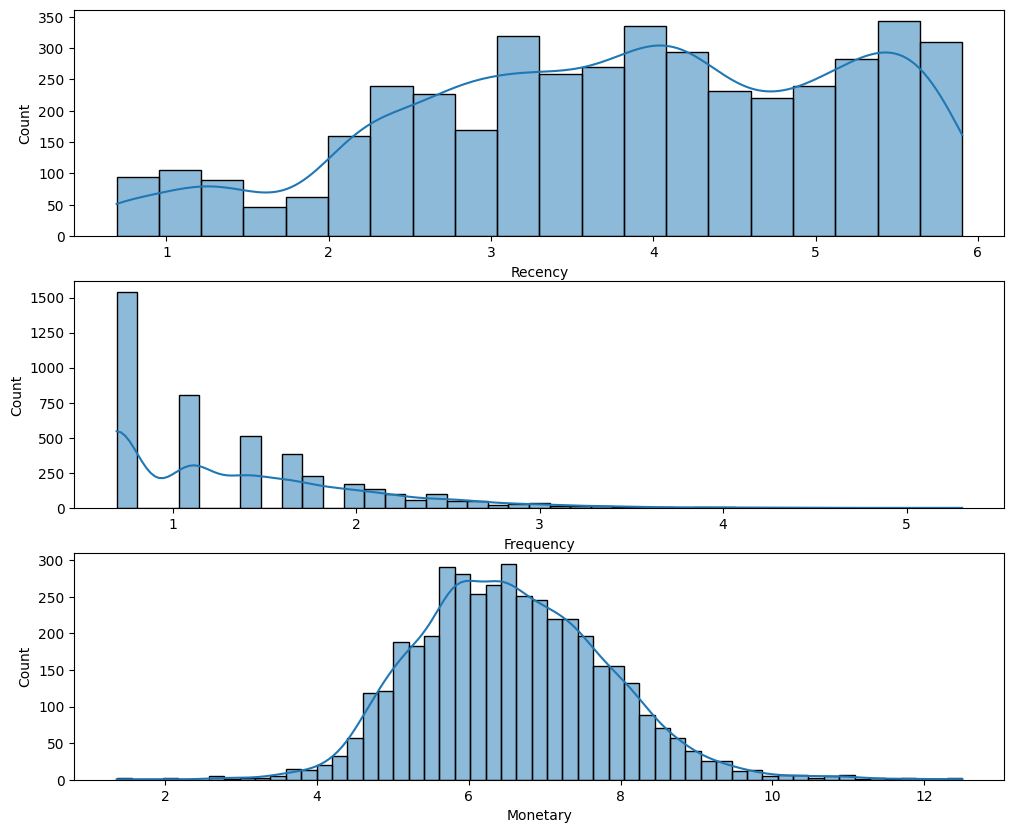

In [156]:
# Sử dụng log(x+1) để tránh lỗi nếu có giá trị 0
rfm_log = rfm[['Recency', 'Frequency', 'Monetary']].apply(np.log1p)

# vẽ lại biểu đồ sau khi log transformation
fig, axes = plt.subplots(3, 1, figsize=(12, 10))
sns.histplot(rfm_log['Recency'], kde=True, ax=axes[0])
sns.histplot(rfm_log['Frequency'], kde=True, ax=axes[1])
sns.histplot(rfm_log['Monetary'], kde=True, ax=axes[2])
plt.show()

In [157]:
from sklearn.preprocessing import StandardScaler


# Khởi tạo scaler
scaler = StandardScaler()

# Fit và transform dữ liệu đã lấy log
rfm_scaled = scaler.fit_transform(rfm_log)

# Chuyển thành DataFrame để tiện quan sát
rfm_scaled_df = pd.DataFrame(rfm_scaled, index=rfm.index, columns=rfm_log.columns)

print("Dữ liệu sau khi chuẩn hóa (Standardized):")
rfm_scaled_df

Dữ liệu sau khi chuẩn hóa (Standardized):


,Recency,Frequency,Monetary
CustomerID,,,
12346,1.452988,-0.938543,3.751585
12347,-0.263742,0.919625,1.401582
12348,0.299779,0.420550,0.745183
12349,-1.062062,-0.938543,0.727335
12350,1.416865,-0.938543,-0.597713
...,...,...,...
18280,1.330658,-0.938543,-1.088345
18281,0.997878,-0.938543,-1.725937
18282,0.718149,-0.938543,-1.555859


# Phân nhóm theo phân vị

In [158]:
import matplotlib.pyplot as plt

try:
    import squarify
except ImportError as e:
    raise ImportError("Chưa cài squarify. Hãy chạy: !pip install squarify") from e

# 1. Chia RFM thành 5 phần
# Recency nhỏ là tốt (điểm 5), Frequency và Monetary lớn là tốt (điểm 5)
r_labels = list(range(5, 0, -1))
f_labels = list(range(1, 6))
m_labels = list(range(1, 6))

rfm['R_score'] = pd.qcut(rfm['Recency'].rank(method='first'), q=5, labels=r_labels)
rfm['F_score'] = pd.qcut(rfm['Frequency'].rank(method='first'), q=5, labels=f_labels)
rfm['M_score'] = pd.qcut(rfm['Monetary'].rank(method='first'), q=5, labels=m_labels)

rfm

,Recency,Frequency,Monetary,returned,R_score,F_score,M_score
CustomerID,,,,,,,
12346,317,1,77183.60,0,1,1,5
12347,31,6,4085.18,1,4,5,5
12348,67,4,1797.24,0,3,4,4
12349,10,1,1757.55,0,5,1,4
12350,302,1,334.40,0,1,1,2
...,...,...,...,...,...,...,...
18280,269,1,180.60,0,1,2,1
18281,172,1,80.82,0,2,2,1
18282,118,1,100.21,1,2,2,1


In [159]:
# Xây dựng hàm Segment Map theo R và F
def create_segment(df):
    r = int(df['R_score'])
    f = int(df['F_score'])
    
    if r >= 4 and f >= 4:
        return 'VIP'
    elif r < 4 and f >= 4:
        return 'Loyalty'
    elif r >= 4 and f < 4:
        return 'New'
    else:
        return 'Hibernate'

rfm['Segment'] = rfm.apply(create_segment, axis=1)

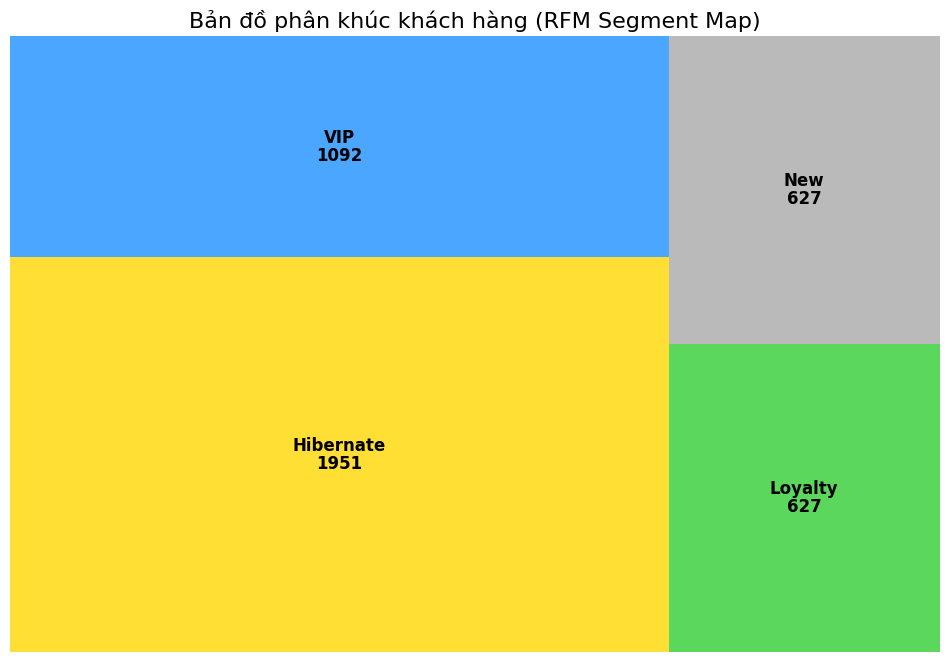

Recency Frequency Monetary      
             mean      mean     mean count
Segment                                   
Hibernate   160.2       1.4    588.5  1951
Loyalty      90.2       5.1   1941.9   627
New          15.7       1.7    581.5   627
VIP          12.8       9.8   5164.6  1092

In [160]:
# 3. Thống kê và Trực quan hóa bằng Treemap
seg_data = rfm['Segment'].value_counts().reset_index()
seg_data.columns = ['Segment', 'Count']

plt.figure(figsize=(12, 8))
colors = ['#FFD700', '#1E90FF', '#32CD32', '#A9A9A9'] # Vàng (VIP), Xanh (Loyalty), Lá (New), Xám (Hibernate)
squarify.plot(sizes=seg_data['Count'], label=seg_data['Segment'], 
              color=colors, alpha=0.8, value=seg_data['Count'], text_kwargs={'fontsize':12, 'weight':'bold'})

plt.title('Bản đồ phân khúc khách hàng (RFM Segment Map)', fontsize=16)
plt.axis('off')
plt.show()

# Hiển thị bảng tổng hợp chi tiết
display(rfm.groupby('Segment').agg({
    'Recency': 'mean',
    'Frequency': 'mean',
    'Monetary': ['mean', 'count']
}).round(1))

In [161]:
# test xem mô hình có phân loại đúng không

# Gán nhãn cụm vào dữ liệu test
df_test = df[df['InvoiceDate'] >= '2011-12-01']
returning_customers = df_test['CustomerID'].astype(int).astype(str).unique()
rfm['returned'] = rfm.index.isin(returning_customers).astype(int)

returnrate_segment = rfm.groupby('Segment')['returned'].mean().sort_values(ascending=False)
print("Tỷ lệ khách hàng quay lại theo từng phân khúc:")
print(returnrate_segment)

Tỷ lệ khách hàng quay lại theo từng phân khúc:
Segment
VIP          0.293956
Loyalty      0.133971
New          0.102073
Hibernate    0.053819
Name: returned, dtype: float64


Nhóm VIP: Khách hàng VIP có tỷ lệ quay lại trong Tháng 12 ~ 29%

Nhóm Loyalty: Khách hàng trung thành có tỷ lệ quay lại trong Tháng 12 ~ 14%

Nhóm New: Khách hàng vãng lai có tỷ lệ quay lại ~ 10%

Nhóm Hibernate: Khách hàng 'ngủ đông' có tỷ lệ quay lại ~ 5%

=> Nhìn chung, các con số này đã phản ánh được tính logic của tập khách hàng đã phân loại

# Phân nhóm theo K-MEANS

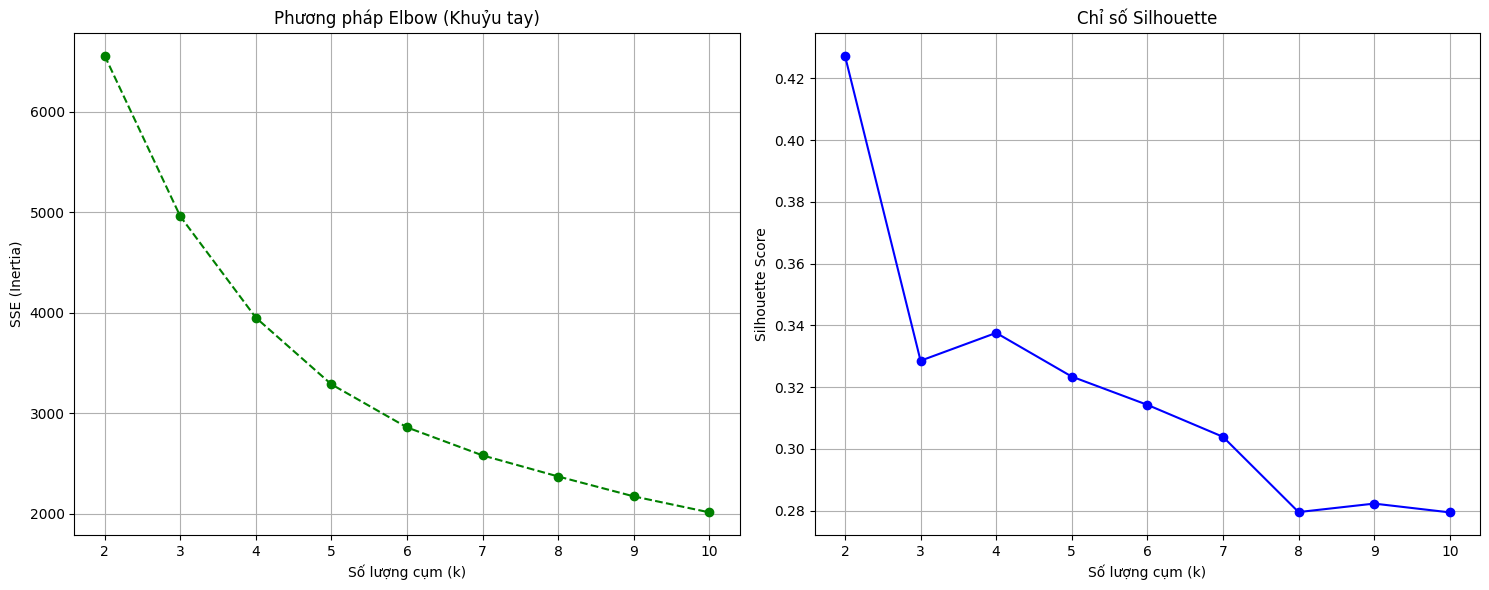

In [162]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

# 1. Chuẩn bị danh sách để lưu kết quả
sse = {}   # Sum of Squared Errors
sil = []   # Silhouette Scores
k_range = range(2, 11)  # Thử nghiệm k từ 2 đến 10

# 2. Chạy vòng lặp thử nghiệm các giá trị k
for k in k_range:
    kmeans = KMeans(n_clusters=k, init='k-means++', random_state=42, n_init=10)
    labels = kmeans.fit_predict(rfm_scaled_df)

    # Lưu Inertia (SSE)
    sse[k] = kmeans.inertia_

    # Tính Silhouette Score
    sil.append(silhouette_score(rfm_scaled_df, labels))

# 3. Vẽ biểu đồ so sánh
plt.figure(figsize=(15, 6))

# Biểu đồ Elbow
plt.subplot(1, 2, 1)
plt.plot(list(sse.keys()), list(sse.values()), 'go--')
plt.title('Phương pháp Elbow (Khuỷu tay)')
plt.xlabel('Số lượng cụm (k)')
plt.ylabel('SSE (Inertia)')
plt.grid(True)

# Biểu đồ Silhouette
plt.subplot(1, 2, 2)
plt.plot(k_range, sil, 'bo-')
plt.title('Chỉ số Silhouette')
plt.xlabel('Số lượng cụm (k)')
plt.ylabel('Silhouette Score')
plt.grid(True)

plt.tight_layout()
plt.show()

In [163]:
from sklearn.cluster import KMeans

# 1. Khởi tạo và huấn luyện mô hình với k=4
kmeans = KMeans(n_clusters=4, init='k-means++', random_state=42, n_init=10)
rfm['Cluster'] = kmeans.fit_predict(rfm_scaled_df)

# 2. Tính toán đặc điểm trung bình của mỗi cụm
cluster_profile = rfm.groupby('Cluster').agg({
    'Recency': 'mean',
    'Frequency': 'mean',
    'Monetary': ['mean', 'count']
}).round(1)

# Đổi tên cột cho rõ ràng
cluster_profile.columns = ['Recency_Mean', 'Frequency_Mean', 'Monetary_Mean', 'Count']
cluster_profile = cluster_profile.sort_values(by='Monetary_Mean', ascending=False)

print("Đặc điểm của 4 phân khúc khách hàng:")
display(cluster_profile)

# 3. Gán tên cụm theo profile thực tế, không hard-code số cụm
cluster_stats = cluster_profile.copy()
vip_cluster = cluster_stats.sort_values(['Monetary_Mean', 'Frequency_Mean'], ascending=[False, False]).index[0]
hibernate_cluster = cluster_stats.sort_values(['Recency_Mean', 'Frequency_Mean', 'Monetary_Mean'],
                                              ascending=[False, True, True]).index[0]

remaining_clusters = [c for c in cluster_stats.index if c not in [vip_cluster, hibernate_cluster]]
remaining_by_recency = cluster_stats.loc[remaining_clusters].sort_values('Recency_Mean').index.tolist()

new_cluster = remaining_by_recency[0]
loyalty_cluster = remaining_by_recency[1]

kmeans_label_map = {
    vip_cluster: 'VIP',
    loyalty_cluster: 'Loyalty',
    new_cluster: 'New',
    hibernate_cluster: 'Hibernate'
}

Đặc điểm của 4 phân khúc khách hàng:


,Recency_Mean,Frequency_Mean,Monetary_Mean,Count
Cluster,,,,
3,12.1,14.2,8263.2,623
1,60.1,4.2,1850.4,1199
0,19.2,1.9,478.6,874
2,185.3,1.4,365.5,1601


**Diễn giải K-means**

Tên cụm được gán **dựa trên profile thực tế của từng cụm** (`Recency`, `Frequency`, `Monetary`), không gắn cứng kiểu `cụm 3 = VIP`.

- **VIP**: Monetary và Frequency cao nhất
- **Hibernate**: Recency cao, Frequency/Monetary thấp
- Hai cụm còn lại:
  - **New**: Recency thấp hơn
  - **Loyalty**: ổn định hơn về Frequency/Monetary

In [164]:
# Đặt tên cho các cụm K-means theo mapping đã suy ra từ cluster_profile
# Tạo từ điển ánh xạ thủ công
kmeans_label_map = {
    3: 'VIP',
    1: 'Loyalty',
    0: 'New',
    2: 'Hibernate'
}

rfm['KMeans_Segment'] = rfm['Cluster'].map(kmeans_label_map)
rfm

,Recency,Frequency,Monetary,returned,R_score,F_score,M_score,Segment,Cluster,KMeans_Segment
CustomerID,,,,,,,,,,
12346,317,1,77183.60,0,1,1,5,Hibernate,1,Loyalty
12347,31,6,4085.18,1,4,5,5,VIP,1,Loyalty
12348,67,4,1797.24,0,3,4,4,Loyalty,1,Loyalty
12349,10,1,1757.55,0,5,1,4,New,0,New
12350,302,1,334.40,0,1,1,2,Hibernate,2,Hibernate
...,...,...,...,...,...,...,...,...,...,...
18280,269,1,180.60,0,1,2,1,Hibernate,2,Hibernate
18281,172,1,80.82,0,2,2,1,Hibernate,2,Hibernate
18282,118,1,100.21,1,2,2,1,Hibernate,2,Hibernate


In [165]:
# Kiểm tra tỷ lệ khách hàng quay lại theo từng cụm / từng nhãn
returnrate_kmeans = rfm.groupby('KMeans_Segment')['returned'].mean().sort_values(ascending=False)
print("Tỷ lệ khách hàng quay lại theo từng cụm K-means:")
print(returnrate_kmeans)

Tỷ lệ khách hàng quay lại theo từng cụm K-means:
KMeans_Segment
VIP          0.393258
Loyalty      0.143453
New          0.092677
Hibernate    0.047470
Name: returned, dtype: float64


Sau khi chạy lại cell trên, hãy đọc kết quả theo **KMeans_Segment** thay vì theo số cụm thô (`0, 1, 2, 3`), vì số cụm có thể thay đổi khi dữ liệu hoặc tham số thay đổi.

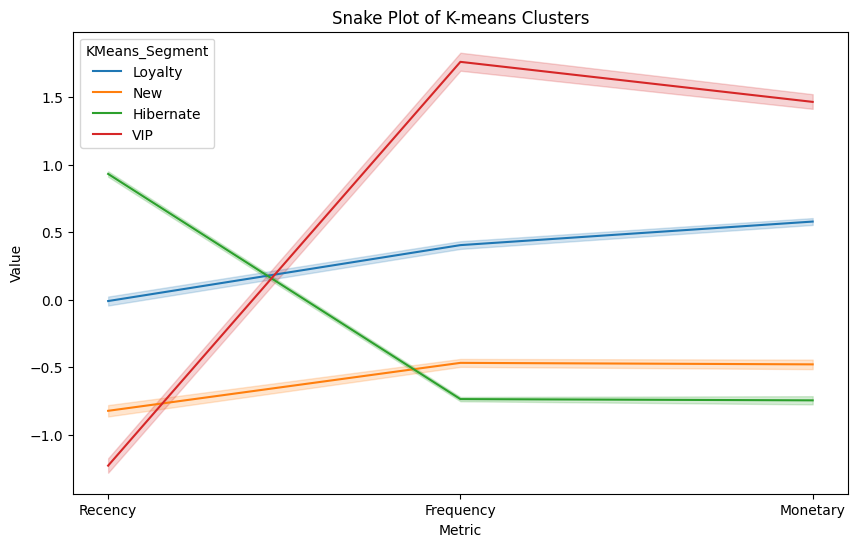

In [166]:
# Snake plot cho K-means cluster
plot_kmeans = rfm_scaled_df.copy()
plot_kmeans['Cluster'] = rfm['Cluster']
plot_kmeans['KMeans_Segment'] = rfm['KMeans_Segment']

rfm_melted = pd.melt(
    plot_kmeans.reset_index(),
    id_vars=['CustomerID', 'Cluster','KMeans_Segment'],
    value_vars=['Recency', 'Frequency', 'Monetary'],
    var_name='Metric',
    value_name='Value'
)

plt.figure(figsize=(10, 6))
sns.lineplot(data=rfm_melted, x='Metric', y='Value', hue='KMeans_Segment')
plt.title('Snake Plot of K-means Clusters')
plt.show()

# Phân nhóm theo GMM

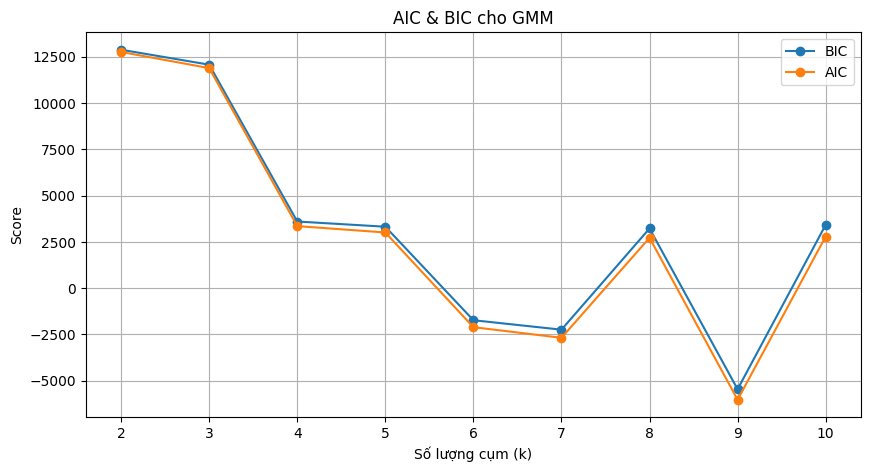

In [167]:
from sklearn.mixture import GaussianMixture
import matplotlib.pyplot as plt

n_components = range(2, 11)
models = [
    GaussianMixture(n, covariance_type='full', random_state=42).fit(rfm_scaled_df)
    for n in n_components
]

plt.figure(figsize=(10, 5))
plt.plot(n_components, [m.bic(rfm_scaled_df) for m in models], label='BIC', marker='o')
plt.plot(n_components, [m.aic(rfm_scaled_df) for m in models], label='AIC', marker='o')
plt.legend(loc='best')
plt.xlabel('Số lượng cụm (k)')
plt.ylabel('Score')
plt.title('AIC & BIC cho GMM')
plt.grid(True)
plt.show()

In [168]:
# Khởi tạo GMM với k=4
gmm = GaussianMixture(n_components=4, covariance_type='full', random_state=42)
gmm.fit(rfm_scaled_df)

# Gán nhãn cụm (Hard Assignment)
rfm['GMM_Cluster'] = gmm.predict(rfm_scaled_df)

# Lấy xác suất thuộc về các cụm (Soft Assignment)
probs = gmm.predict_proba(rfm_scaled_df)
rfm['Cluster_Probability'] = probs.max(axis=1).round(4)  # Xác suất cao nhất

# Tính toán đặc điểm trung bình của GMM Cluster
gmm_profile = rfm.groupby('GMM_Cluster').agg({
    'Recency': 'mean',
    'Frequency': 'mean',
    'Monetary': ['mean', 'count'],
    'Cluster_Probability': 'mean'
}).round(1)

gmm_profile.columns = ['Recency_Mean', 'Frequency_Mean', 'Monetary_Mean', 'Count', 'Avg_Confidence']
gmm_profile = gmm_profile.sort_values(by='Monetary_Mean', ascending=False)

print("Kết quả phân khúc bằng GMM:")
display(gmm_profile)


Kết quả phân khúc bằng GMM:


,Recency_Mean,Frequency_Mean,Monetary_Mean,Count,Avg_Confidence
GMM_Cluster,,,,,
3,17.2,12.6,6724.5,784,0.9
1,62.6,4.0,1640.0,1169,0.9
2,94.5,2.0,684.3,806,1.0
0,149.7,1.0,409.2,1538,1.0


**Diễn giải GMM**

Tương tự K-means, nhãn cụm của GMM được gán **theo profile thực tế của cụm** sau khi fit mô hình, tránh lỗi logic khi giả định trước rằng một số cụm cố định sẽ luôn đại diện cho cùng một nhóm khách hàng.

In [169]:
# Đặt tên cho các cụm GMM theo mapping đã suy ra từ gmm_profile
# Tạo từ điển ánh xạ thủ công
gmm_label_map = {
    3: 'VIP',
    1: 'Loyalty',
    2: 'New',
    0: 'Hibernate'
}

rfm['GMM_Segment'] = rfm['GMM_Cluster'].map(gmm_label_map)
rfm

,Recency,Frequency,Monetary,returned,R_score,F_score,M_score,Segment,Cluster,KMeans_Segment,GMM_Cluster,Cluster_Probability,GMM_Segment
CustomerID,,,,,,,,,,,,,
12346,317,1,77183.60,0,1,1,5,Hibernate,1,Loyalty,0,1.0000,Hibernate
12347,31,6,4085.18,1,4,5,5,VIP,1,Loyalty,1,0.7268,Loyalty
12348,67,4,1797.24,0,3,4,4,Loyalty,1,Loyalty,1,0.9533,Loyalty
12349,10,1,1757.55,0,5,1,4,New,0,New,0,1.0000,Hibernate
12350,302,1,334.40,0,1,1,2,Hibernate,2,Hibernate,0,1.0000,Hibernate
...,...,...,...,...,...,...,...,...,...,...,...,...,...
18280,269,1,180.60,0,1,2,1,Hibernate,2,Hibernate,0,1.0000,Hibernate
18281,172,1,80.82,0,2,2,1,Hibernate,2,Hibernate,0,1.0000,Hibernate
18282,118,1,100.21,1,2,2,1,Hibernate,2,Hibernate,0,1.0000,Hibernate


In [170]:
# Kiểm tra tỷ lệ khách hàng quay lại theo từng cụm GMM
returnrate_gmm = rfm.groupby('GMM_Segment')['returned'].mean().sort_values(ascending=False)
print("Tỷ lệ khách hàng quay lại theo từng cụm GMM:")
print(returnrate_gmm)

Tỷ lệ khách hàng quay lại theo từng cụm GMM:
GMM_Segment
VIP          0.346939
Loyalty      0.142857
New          0.062035
Hibernate    0.055267
Name: returned, dtype: float64


Nếu GMM và K-means cho thứ tự nhóm khá giống nhau thì đó là dấu hiệu tốt. Tuy nhiên, cần so sánh dựa trên **segment name** và **profile cụm**, không chỉ nhìn vào mã cụm số học.

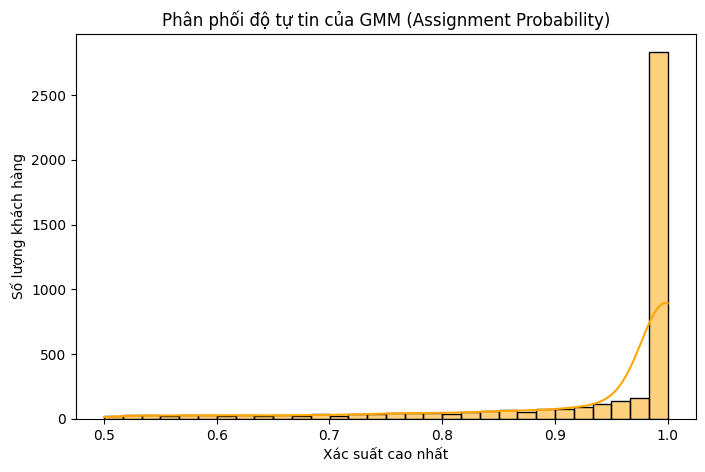

In [171]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
sns.histplot(rfm['Cluster_Probability'], bins=30, kde=True, color='orange')
plt.title('Phân phối độ tự tin của GMM (Assignment Probability)')
plt.xlabel('Xác suất cao nhất')
plt.ylabel('Số lượng khách hàng')
plt.show()

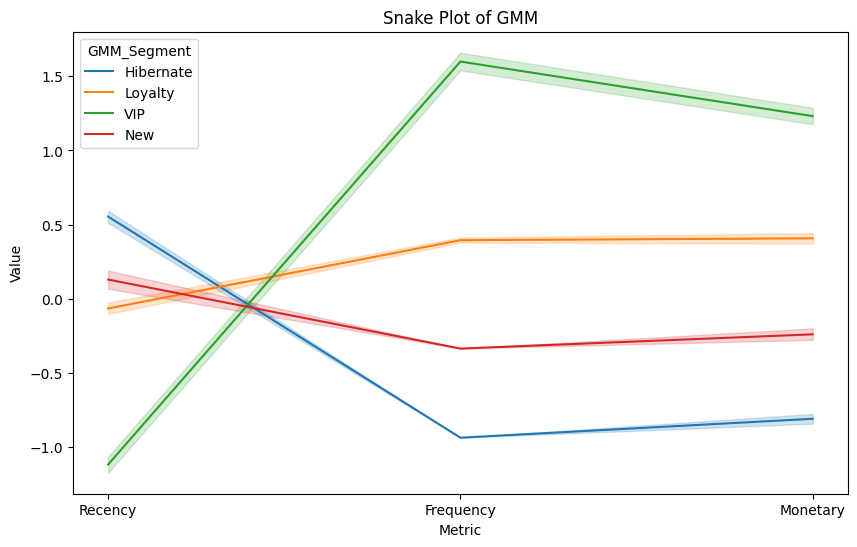

In [172]:
# Snake plot cho GMM Cluster
plot_gmm = rfm_scaled_df.copy()
plot_gmm['GMM_Cluster'] = rfm['GMM_Cluster']
plot_gmm['GMM_Segment'] = rfm['GMM_Segment']

rfm_melted = pd.melt(
    plot_gmm.reset_index(),
    id_vars=['CustomerID', 'GMM_Cluster', 'GMM_Segment'],
    value_vars=['Recency', 'Frequency', 'Monetary'],
    var_name='Metric',
    value_name='Value'
)

plt.figure(figsize=(10, 6))
sns.lineplot(data=rfm_melted, x='Metric', y='Value', hue='GMM_Segment')
plt.title('Snake Plot of GMM')
plt.show()

# So sánh K-means và GMM

In [173]:
conf_matrix = pd.crosstab(rfm['KMeans_Segment'], rfm['GMM_Segment'])
print("Bảng đối chiếu K-means vs GMM:")
display(conf_matrix)

Bảng đối chiếu K-means vs GMM:


GMM_Segment,Hibernate,Loyalty,New,VIP
KMeans_Segment,,,,
Hibernate,1143,100,358,0
Loyalty,23,904,144,128
New,372,135,304,63
VIP,0,30,0,593
